Santiago Andrés Acosta Díaz 

# Agujeros negros supermasivos

Para esto, tenemos que usar los datos en `SMBHData`, que están escritos en formato `.dat`, por lo que hay que hay que usar `astropy` para leerla.

In [3]:
import numpy as np
from astropy.io import ascii
import matplotlib.pyplot as plt 

data = ascii.read('data/SMBHData/table1.dat', readme = 'data/SMBHData/ReadMe')

Ahora, lo que nos importa es hacer la regresión de 

$$
    \log(M_{_{BH}}) = \theta_0 + \theta_1 \log(\sigma^*/\sigma_0)
$$

y de

$$
    \log(M_{_{BH}}) = \theta_0 + \theta_1 \log(FWHM)
$$


En este caso, nos interesan las columnas `logM`, `sigma*` y `FWHM` del dataset. Como podemos ver, $M_{_{BHM}}$ ya está entregado el logaritmo, por lo tanto, tenemos que obtener el logaritmo de las otras cantidades. 

Entonces, vamos a guardar todas estas cantidades. Así mismo, vamos a filtrarlas de tal manera que `sigma*` y `FWHM` tengan las mismas entradas que `logM`.

In [4]:
logM = data["logM"]
sigma = data["sigma*"]
FWHM = data["FWHM"]

# Limpiamos las columnas 
mask1 = np.isfinite(logM) & np.isfinite(sigma)
mask2 = np.isfinite(logM) & np.isfinite(FWHM) & np.isreal(FWHM) # También limpiamos que hayan datos

clean1_logM = logM[mask1]
clean1_sigma = sigma[mask1]

clean2_logM = logM[mask2]
clean2_FWHM = FWHM[mask2]

Ahora, algo importante a hacer es hallar $\sigma_0$. De las ecuaciones se intulle que $FWHM = \sigma^* / \sigma_0$, entonces podemos hacer una estimación de este valor

In [5]:
sigma_0 = np.mean(sigma / FWHM)
print(f"Estimación de sigma_0: {sigma_0}")

Estimación de sigma_0: 0.04080296803861139


Ahora, utilizamos la clase de `LinearRegressor` de scipy

Usando sigma
Slope: 2.9254
Intercept: -3.1333

Usando FWHM
Slope: 2.4708
Intercept: -1.6822


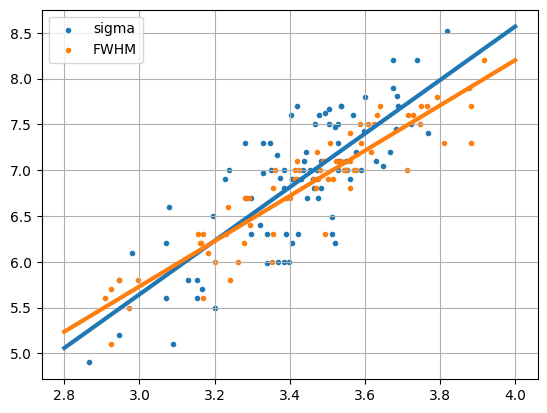

In [6]:
from sklearn.linear_model import LinearRegression

# Creamos el modelo
model = LinearRegression()
model.fit(np.log10(clean1_sigma/sigma_0).reshape(-1, 1), clean1_logM)

# Obtenemos los parámetros
slope1 = model.coef_[0]
intercept1 = model.intercept_

# Revisamos resultados
print("Usando sigma")
print(f"Slope: {slope1:.4f}")
print(f"Intercept: {intercept1:.4f}")

# Creamos el modelo
model = LinearRegression()
model.fit(np.log10(clean2_FWHM).reshape(-1, 1), clean2_logM)

# Obtenemos los parámetros
slope2 = model.coef_[0]
intercept2 = model.intercept_

# Revisamos resultados
print()
print("Usando FWHM")
print(f"Slope: {slope2:.4f}")
print(f"Intercept: {intercept2:.4f}")


x = np.linspace(2.8, 4.0, 100)
y1 = intercept1 + slope1 * x
y2 = intercept2 + slope2 * x

plt.scatter(np.log10(clean1_sigma/sigma_0), clean1_logM, label = "sigma", marker = '.')
plt.scatter(np.log10(clean2_FWHM), clean2_logM, label = "FWHM", marker = '.')
plt.plot(x, y1, lw = 3.0)
plt.plot(x, y2, lw = 3.0)

plt.grid()
plt.legend()
plt.show()

Vemos que, en general, estos resultados difieren por, posiblemente, el ruido en el $\sigma_0$ hallado (por inconsistencias entre $FWHM$ y $\sigma^*$). 

Pero en general, los resultados son parecidos. 

La idea de este ejercicio, supongo, era revisar el filtro de los datos, y se logró.

# Lo mismo pero con las simultaneas

Ahora, tenemos que resolver

$$
    y = \theta_0 + \theta_1 \log(\sigma^*) + \theta_2 \log(FWHM)
$$

__NOTA:__ _supongo que, en vez de $y$, el profesor se refiere a $z$_

Para esto, vamos a usar el LinearRegression, Ridge y Lasso regresors de la librería sklearn. 

Primero, limpiamos los datos, y luego, revisamos los modelos en 3D 



In [42]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split

# Cargamos la data
z = data["z"]
sigma = data["sigma*"]
FWHM = data["FWHM"]

# Limpiamos la data
mask = np.isfinite(z) & np.isfinite(sigma) & np.isfinite(FWHM) & np.isreal(FWHM)

z_clean = np.array(z[mask])
sigma_clean = np.log10(np.array(sigma[mask]))   # A estos dos les sacamos el log de una vez
FWHM_clean = np.log10(np.array(FWHM[mask]))

# Creamos una matriz con nuestros valores de x
X = np.column_stack((sigma_clean, FWHM_clean))

# CREACIÓN DE LOS SETS
# Como vamos a evaluar con sets y todo eso, spliteamos los datos
X_train, X_test, y_train, y_test = train_test_split(
    X, z_clean, test_size=0.2, random_state=89
)

# Creamos nuestros modelos: para ridge y laso elegimos un lambda no muy fuerte
models = {
    'OLS': LinearRegression(),
    'Ridge': Ridge(alpha=1.5),
    'Lasso': Lasso(alpha=1e-3)}


# Entrenamos y revisamos 
for name, model in models.items():
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    
    # Obtemeos coeficientes
    theta_0 = model.intercept_
    theta_1 = model.coef_[0]  
    theta_2 = model.coef_[1] 

    # imprimimos
    print(f"\n{name} Results:")
    print(f"theta_0: {theta_0:.4f}")
    print(f"theta_1: {theta_1:.4f}")
    print(f"theta_2: {theta_2:.4f}")
    print(f"R2: {r2:.4f} para un trainset de tramaño {len(y_train)}")



OLS Results:
theta_0: 0.1734
theta_1: -0.0329
theta_2: -0.0152
R2: -0.4047 para un trainset de tramaño 56

Ridge Results:
theta_0: 0.1408
theta_1: -0.0170
theta_2: -0.0151
R2: -0.2830 para un trainset de tramaño 56

Lasso Results:
theta_0: 0.0970
theta_1: -0.0008
theta_2: -0.0119
R2: -0.1563 para un trainset de tramaño 56


Vemos, en general, que Ridge y Lasso tienen un mejor performance en materia de evitar el Overfitting gracias a la penalización al mismo que tienen. Claramente, al elegir diferentes valores de $\alpha$ para estos métodos, uno podría llegar a mejores resultados.

Ahora, revisemos el comportamiento del $R^2$ a medida que cambiamos el tamaño del train set.

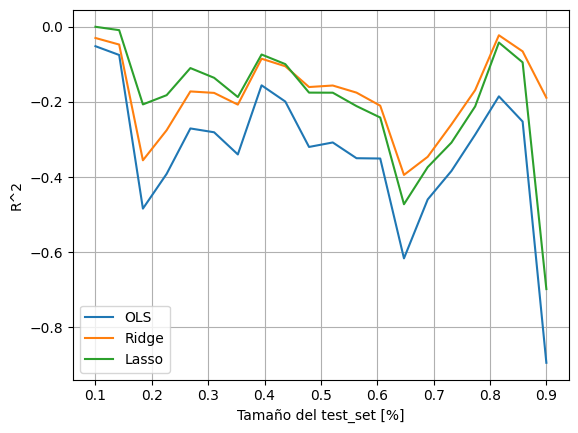

In [53]:
# Entrenamos y revisamos 

# CREACIÓN DE LOS SETS
# Como vamos a evaluar con sets y todo eso, spliteamos los datos

for name, model in models.items():

    erres = list()
    test_sizes = np.linspace(0.1, 0.9, 20)
    
    for i in test_sizes:
        
        X_train, X_test, y_train, y_test = train_test_split(
            X, z_clean, test_size=i, random_state=89
        )
        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_test)
        r2 = r2_score(y_test, y_pred)

        erres.append(r2)

    plt.plot(test_sizes, erres, label = {name})


plt.ylabel(r"R^2")
plt.xlabel(r"Tamaño del test_set [%]")
plt.legend()
plt.grid()
plt.show()
    

El anterior análisis no nos da mucha información puesto que el dataset usado es muy pequeño, pero pues, ahí está lo que se nos pidió.